<a href="https://colab.research.google.com/github/Yuktatiwari1105/Loan_Default_Prediction/blob/main/LoanDefault_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1 - Loading Dataset and cleaning

In [ ]:
# Installing basic libraries
!pip install pandas numpy matplotlib seaborn scikit-learn
print("Libraries installed")

Libraries installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

print("Libraries imported")

Libraries imported


In [ ]:
# Dataset is present in google drive and is connected to the project
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading lendingclub dataset from google drive
df = pd.read_csv(
    '/content/drive/MyDrive/LoanProject/accepted_2007_to_2018Q4.csv',
    low_memory=False
)

print("Lendinclub dataset loaded")
print("Shape-", df.shape)

Lendinclub dataset loaded
Shape- (2260701, 151)


In [ ]:
# Checking which all data columns exists in the dataset
print("Column names-")
print(df.columns.tolist())


# Checking first 5 rows
print("First 5 rows-")
display(df.head())

print("Shape-", df.shape)

Column names-
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'ac

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Shape- (2260701, 151)


In [ ]:
# Select the target feature " loan_status" and check what values are in the target column
print("Loan Status values:")
print(df['loan_status'].value_counts())

Loan Status values:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [ ]:
# I'm only keeping only Fully Paid and Charged Off
df = df[df['loan_status'].isin(
    ['Fully Paid', 'Charged Off']
)]

# Convert to numbers,  0 means Charged off, 1 means Fully Paid
df['loan_status'] = df['loan_status'].map(
    {'Fully Paid': 1, 'Charged Off': 0}
)

print("After filteration:")
print(df['loan_status'].value_counts())
print("Total records remaining:", len(df))

After filteration:
loan_status
1    1076751
0     268559
Name: count, dtype: int64
Total records remaining: 1345310


In [ ]:
# checking missing values in each column
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)

print("Columns with missing values:")
print(missing.head(20))

Columns with missing values:
member_id                                     1345310
next_pymnt_d                                  1345310
orig_projected_additional_accrued_interest    1341551
hardship_length                               1339556
hardship_dpd                                  1339556
hardship_last_payment_amount                  1339556
hardship_payoff_balance_amount                1339556
deferral_term                                 1339556
payment_plan_start_date                       1339556
hardship_amount                               1339556
hardship_end_date                             1339556
hardship_loan_status                          1339556
hardship_type                                 1339556
hardship_start_date                           1339556
hardship_reason                               1339556
hardship_status                               1339556
sec_app_mths_since_last_major_derog           1338665
sec_app_revol_util                            1327008

In [ ]:
# these are useless or have too many missing values manually selected
drop_columns = [
    'member_id',
    'next_pymnt_d',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'hardship_reason',
    'hardship_type',
    'hardship_status',
    'hardship_amount',
    'deferral_term',
    'hardship_end_date',
    'hardship_dpd',
    'hardship_loan_status',
    'hardship_length',
    'payment_plan_start_date',
    'hardship_start_date',
    'debt_settlement_flag_date',
    'settlement_percentage',
    'settlement_date',
    'settlement_term',
    'settlement_status',
    'settlement_amount',
]

In [ ]:
# Actually drop the manually identified unwanted columns
existing_drop_columns = [col for col in drop_columns if col in df.columns]

print(f"Dropping {len(existing_drop_columns)} manually selected columns")
df = df.drop(columns=existing_drop_columns)
print("Shape after manual drop:", df.shape)

Dropping 22 manually selected columns
Shape after manual drop: (1345310, 129)


In [ ]:
# Manually selected the final features after dropping 22 unwanted features
selected_features = [
    'loan_amnt','int_rate','installment','annual_inc','dti',
    'delinq_2yrs','open_acc','pub_rec','revol_bal','revol_util',
    'total_acc','emp_length','home_ownership','verification_status','purpose',
    'term','desc','loan_status'
]

existing_features = [
    col for col in selected_features
    if col in df.columns
]

df = df[existing_features]
print("Features selected:", existing_features)
print("Shape:", df.shape)

Features selected: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'term', 'desc', 'loan_status']
Shape: (1345310, 18)


In [ ]:
if 'desc' in df.columns:
    df['desc'] = df['desc'].fillna('')
    print("Description column found")
    print("Empty descriptions:",
          (df['desc'] == '').sum())
else:
    df['desc'] = ''
    print("No description column found")

Description column found
Empty descriptions: 1221780


In [ ]:
numerical_cols = df.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

if 'loan_status' in numerical_cols:
    numerical_cols.remove('loan_status')

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

cols_to_exclude = ['desc', 'loan_status']
categorical_cols = [
    col for col in categorical_cols
    if col not in cols_to_exclude
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values filled")
remaining = df.isnull().sum()[df.isnull().sum() > 0]
if len(remaining) == 0:
    print("No missing values remaining")
else:
    print(remaining)

Missing values filled
No missing values remaining


In [ ]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")

print("Shape after encoding:", df.shape)

Encoded: emp_length
Encoded: home_ownership
Encoded: verification_status
Encoded: purpose
Encoded: term
Shape after encoding: (1345310, 18)


In [ ]:
scaler = MinMaxScaler()

df[numerical_cols] = scaler.fit_transform(
    df[numerical_cols]
)

print("Normalisation complete")

Normalisation complete


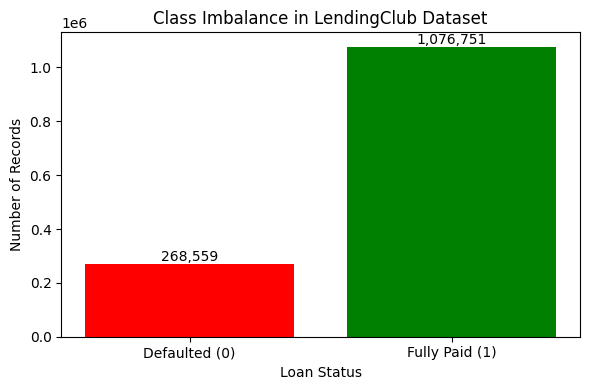

In [ ]:
class_counts = df['loan_status'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Defaulted (0)', 'Fully Paid (1)'],
    [class_counts[0], class_counts[1]],
    color=['red', 'green']
)

for bar, count in zip(
    bars, [class_counts[0], class_counts[1]]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{count:,}',
        ha='center', va='bottom'
    )

plt.title('Class Imbalance in LendingClub Dataset')
plt.xlabel('Loan Status')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [ ]:
save_path = (
    '/content/drive/MyDrive/LoanProject/'
    'cleaned_loan_data.csv'
)

df.to_csv(save_path, index=False)

print("Phase 1 Complete")
print(f"Final shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Defaulted: {(df['loan_status']==0).sum():,}")
print(f"Fully Paid: {(df['loan_status']==1).sum():,}")

Phase 1 Complete
Final shape: (1345310, 18)
Total records: 1,345,310
Defaulted: 268,559
Fully Paid: 1,076,751


## Phase 2 - NLP Processing and Feature Engineering

In [ ]:

!pip install nltk imbalanced-learn --quiet
print("done")

done


In [ ]:

import nltk
from nltk.corpus import stopwords
import string
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.sparse as sp


nltk.download('stopwords')
nltk.download('punkt')

print("phase 2 imports done")

phase 2 imports done


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# loading the cleaned file saved at the end of phase 1

df = pd.read_csv(
    '/content/drive/MyDrive/LoanProject/cleaned_loan_data.csv'
)

print("cleaned dataset loaded")
print("shape:", df.shape)
print(df.head())

cleaned dataset loaded
shape: (1345310, 18)
   loan_amnt  int_rate  installment  annual_inc      dti  delinq_2yrs  \
0   0.078481  0.338006     0.068867    0.005000  0.00691     0.000000   
1   0.612658  0.260125     0.475450    0.005910  0.01706     0.025641   
2   0.493671  0.213006     0.249420    0.005728  0.01178     0.000000   
3   0.250633  0.667445     0.166179    0.009495  0.02637     0.025641   
4   0.289873  0.316589     0.233396    0.003091  0.01120     0.000000   

   open_acc  pub_rec  revol_bal  revol_util  total_acc  emp_length  \
0  0.077778      0.0   0.000952    0.033285   0.063218           1   
1  0.244444      0.0   0.007391    0.021517   0.206897           1   
2  0.066667      0.0   0.002709    0.062983   0.091954           1   
3  0.133333      0.0   0.007549    0.072285   0.189655           3   
4  0.055556      0.0   0.003037    0.076656   0.022989           4   

   home_ownership  verification_status  purpose  term desc  loan_status  
0               1     

In [ ]:
# taking a smaller sample so it runs within colab's memory limits
df = df.sample(n=200000, random_state=42).reset_index(drop=True)

print("sampled shape:", df.shape)
print(df['loan_status'].value_counts())

sampled shape: (200000, 18)
loan_status
1    160274
0     39726
Name: count, dtype: int64


In [ ]:


df['desc'] = df['desc'].astype(str)
df['desc'] = df['desc'].replace('nan', '')

print("desc column fixed")
print("data type now:", df['desc'].dtype)

desc column fixed
data type now: object


In [ ]:
# checking how many borrowers actually wrote something
total = len(df)
empty = (df['desc'] == '').sum()
filled = total - empty

print("total records:", f"{total:,}")
print("has description:", f"{filled:,}")
print("empty description:", f"{empty:,}")
print("percentage with text:",
      f"{(filled/total)*100:.1f}%")

real = df[df['desc'] != '']['desc'].head(3)
for i, d in enumerate(real, 1):
    print(f"\nexample {i}:")
    print(d[:200])

total records: 200,000
has description: 18,417
empty description: 181,583
percentage with text: 9.2%

example 1:
  Borrower added on 03/13/13 > I'm paying off two Bank of America credit cards, (27% interest) and closing those accounts.  It will feel great to cut up those cards!<br>

example 2:
  Borrower added on 09/06/12 > For various unforseen reasons I accumilated some major CC debt and credit debt. I currently pay over $900 a month on CC debt payments. I have great employement, payment,

example 3:
  Borrower added on 06/28/12 > Pay off credit card debt. I have 9 credit cards that i would be paying off. With the offer you are giving me, my payments would be about 1/2 of what I send to all the cr


In [ ]:
# cleaning the borrower description text before applying tfidf, removing punctuation, numbers, and stop words and keeping only meaningful words

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # if empty just return empty string
    if text == '' or text is None:
        return ''

    # In step 1 makeing  everything lowercase
    text = text.lower()

    # In step 2 removeing numbers
    text = re.sub(r'\d+', '', text)

    # In step 3 removeing punctuations such as  . , ! ?....
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # In step 4 spliting into individual words
    words = text.split()

    # In step 5 removeing stop words like the and is....
    words = [w for w in words if w not in stop_words]

    # In step 6 joining back into one string
    return ' '.join(words)

df['desc_clean'] = df['desc'].apply(clean_text)


print("text cleaning done")
print("total descriptions cleaned:", len(df['desc_clean']))
print("empty after cleaning:", (df['desc_clean'] == '').sum())


has_text = df[df['desc_clean'] != '']['desc_clean']

if len(has_text) > 0:
    print("\nsample cleaned description:")
    print(has_text.values[0][:200])
else:
    print("\nno descriptions found with text")
    print("checking desc column values:")
    print(df['desc'].value_counts().head(10))

text cleaning done
total descriptions cleaned: 200000
empty after cleaning: 181626

sample cleaned description:
borrower added im paying two bank america credit cards interest closing accounts feel great cut cardsbr


In [ ]:
# checking how many non empty descriptions we have
non_empty = df[df['desc_clean'] != '']['desc_clean']
print("descriptions with actual text:", len(non_empty))

if len(non_empty) == 0:
    print("\nno descriptions found")
    print("the desc column has no text data")
    print("this means tfidf cannot be applied")
    print("we will proceed with structured data only for now")


    tfidf_matrix = sp.csr_matrix(
        (len(df), 1)
    )
    print("empty placeholder created for tfidf matrix")
    print("shape:", tfidf_matrix.shape)

else:
    print("applying tfidf on", len(non_empty), "descriptions")

    tfidf = TfidfVectorizer(max_features=500)
    tfidf_matrix = tfidf.fit_transform(df['desc_clean'])

    print("tfidf applied successfully")
    print("tfidf matrix shape:", tfidf_matrix.shape)
    print("vocabulary size:", len(tfidf.vocabulary_))
    print("\nsome words found:")
    print(list(tfidf.vocabulary_.keys())[:20])

descriptions with actual text: 18374
applying tfidf on 18374 descriptions
tfidf applied successfully
tfidf matrix shape: (200000, 500)
vocabulary size: 500

some words found:
['borrower', 'added', 'im', 'paying', 'two', 'bank', 'america', 'credit', 'cards', 'interest', 'closing', 'accounts', 'feel', 'great', 'cut', 'cardsbr', 'major', 'cc', 'debt', 'currently']


In [ ]:
# separating structured financial features from text and target
structured_cols = [
    col for col in df.columns
    if col not in ['desc', 'desc_clean', 'loan_status']
]

# X is the input features, y is what we want to predict
X_structured = df[structured_cols].values
y = df['loan_status'].values

print("structured features:", structured_cols)
print("X shape:", X_structured.shape)
print("y shape:", y.shape)
print("defaulted (0):", (y==0).sum())
print("fully paid (1):", (y==1).sum())

structured features: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'term']
X shape: (200000, 16)
y shape: (200000,)
defaulted (0): 39726
fully paid (1): 160274


In [ ]:
import scipy.sparse as sp

# structured data as a sparse matrix instead of a dense array
X_structured_sparse = sp.csr_matrix(X_structured.astype(np.float32))

# tfidf_matrix is already sparse - just keep it that way, don't call .toarray()
X_text_sparse = tfidf_matrix.astype(np.float32)

# combine both while staying sparse - this is the key change
X_hybrid_sparse = sp.hstack([X_structured_sparse, X_text_sparse]).tocsr()

print("structured:", X_structured_sparse.shape)
print("text:", X_text_sparse.shape)
print("hybrid:", X_hybrid_sparse.shape)

structured: (200000, 16)
text: (200000, 500)
hybrid: (200000, 516)


In [ ]:
X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_structured_sparse, y, test_size=0.2, random_state=42
)

X_text_train, X_text_test, _, _ = train_test_split(
    X_text_sparse, y, test_size=0.2, random_state=42
)

X_hybrid_train, X_hybrid_test, _, _ = train_test_split(
    X_hybrid_sparse, y, test_size=0.2, random_state=42
)

In [ ]:

# version 1 - structured financial data only
# version 2 - tfidf text features only
# version 3 - both combined (hybrid)

# version 1 structured only
X_struct = X_structured
print("version 1 structured only:", X_struct.shape)

# version 2 text only

X_text = tfidf_matrix.toarray()
print("version 2 text only:", X_text.shape)

# version 3 hybrid combining both

X_hybrid = np.hstack([X_structured, X_text])
print("version 3 hybrid:", X_hybrid.shape)

version 1 structured only: (200000, 16)
version 2 text only: (200000, 500)
version 3 hybrid: (200000, 516)


In [ ]:
# applying smote to balance the training data


print("applying smote...")
smote = SMOTE(random_state=42)

# structured only
print("applying to structured only...")
X_struct_train_sm, y_train_sm = smote.fit_resample(
    X_struct_train, y_train
)

# text only
print("applying to text only...")
X_text_train_sm, _ = smote.fit_resample(
    X_text_train, y_train
)

# hybrid
print("applying to hybrid...")
X_hybrid_train_sm, _ = smote.fit_resample(
    X_hybrid_train, y_train
)

print("\nsmote complete")
print("before smote - defaulted:", (y_train==0).sum())
print("before smote - fully paid:", (y_train==1).sum())
print("after smote - defaulted:", (y_train_sm==0).sum())
print("after smote - fully paid:", (y_train_sm==1).sum())

applying smote...
applying to structured only...
applying to text only...
applying to hybrid...

smote complete
before smote - defaulted: 31728
before smote - fully paid: 128272
after smote - defaulted: 128272
after smote - fully paid: 128272


In [ ]:
# saving all three versions of training and test data
# so phase 3 can just load them directly without redoing this

save_dir = '/content/drive/MyDrive/LoanProject/'

np.save(save_dir + 'X_struct_train.npy', X_struct_train_sm)
np.save(save_dir + 'X_struct_test.npy', X_struct_test)
np.save(save_dir + 'X_text_train.npy', X_text_train_sm)
np.save(save_dir + 'X_text_test.npy', X_text_test)
np.save(save_dir + 'X_hybrid_train.npy', X_hybrid_train_sm)
np.save(save_dir + 'X_hybrid_test.npy', X_hybrid_test)
np.save(save_dir + 'y_train.npy', y_train_sm)
np.save(save_dir + 'y_test.npy', y_test)

print("phase 2 complete - all files saved to google drive")
print("\nsummary:")
print("structured train:", X_struct_train_sm.shape)
print("text train:", X_text_train_sm.shape)
print("hybrid train:", X_hybrid_train_sm.shape)
print("test size:", X_struct_test.shape[0])

phase 2 complete - all files saved to google drive

summary:
structured train: (256544, 16)
text train: (256544, 500)
hybrid train: (256544, 516)
test size: 40000


Phase 3 - Model Training


In [ ]:
# importing tools needed for phase 3 - model training and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import joblib

print("phase 3 imports done")

phase 3 imports done


In [ ]:
!pip install xgboost --quiet
print("xgboost installed")

xgboost installed


In [ ]:
from xgboost import XGBClassifier
print("xgboost imported")

xgboost imported


In [ ]:
load_dir = '/content/drive/MyDrive/LoanProject/'

def load_array(filename):
    arr = np.load(load_dir + filename, allow_pickle=True)
    # if it's a sparse matrix wrapped in an object array, unwrap and densify
    if arr.dtype == object and arr.shape == ():
        arr = arr.item().toarray()
    elif arr.dtype == object:
        arr = np.array(arr.tolist())
    return arr.astype(np.float32)

X_struct_train = load_array('X_struct_train.npy')
X_struct_test = load_array('X_struct_test.npy')
X_text_train = load_array('X_text_train.npy')
X_text_test = load_array('X_text_test.npy')
X_hybrid_train = load_array('X_hybrid_train.npy')
X_hybrid_test = load_array('X_hybrid_test.npy')

y_train = np.load(load_dir + 'y_train.npy', allow_pickle=True).astype(int)
y_test = np.load(load_dir + 'y_test.npy', allow_pickle=True).astype(int)

print("all phase 2 data loaded")
print("structured train:", X_struct_train.shape)
print("text train:", X_text_train.shape)
print("hybrid train:", X_hybrid_train.shape)
print("test size:", X_struct_test.shape[0])

all phase 2 data loaded
structured train: (256544, 16)
text train: (256544, 500)
hybrid train: (256544, 516)
test size: 40000


In [ ]:
# storing results and trained models as we go
results_list = []
trained_models = {}

feature_sets = {
    'Structured': (X_struct_train, X_struct_test),
    'Text': (X_text_train, X_text_test),
    'Hybrid': (X_hybrid_train, X_hybrid_test)
}

print("ready to train")

ready to train


In [ ]:
# one function that trains a model and returns all the metrics
# writing it once so we don't repeat this 9 times

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, feature_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': model_name,
        'Features': feature_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    return model, results

print("evaluation function ready")

evaluation function ready


In [ ]:
print("training logistic regression...")

for feat_name, (X_tr, X_te) in feature_sets.items():
    print("  -", feat_name)
    model, res = train_and_evaluate(
        LogisticRegression(max_iter=1000, random_state=42),
        X_tr, y_train, X_te, y_test,
        'Logistic Regression', feat_name
    )
    trained_models[('Logistic Regression', feat_name)] = (model, X_te)
    results_list.append(res)

print("logistic regression done")

training logistic regression...
  - Structured
  - Text
  - Hybrid
logistic regression done


In [ ]:
print("training random forest...")

for feat_name, (X_tr, X_te) in feature_sets.items():
    print("  -", feat_name)
    model, res = train_and_evaluate(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_tr, y_train, X_te, y_test,
        'Random Forest', feat_name
    )
    trained_models[('Random Forest', feat_name)] = (model, X_te)
    results_list.append(res)

print("random forest done")

training random forest...
  - Structured
  - Text
  - Hybrid
random forest done


In [ ]:
print("training xgboost...")

for feat_name, (X_tr, X_te) in feature_sets.items():
    print("  -", feat_name)
    model, res = train_and_evaluate(
        XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1),
        X_tr, y_train, X_te, y_test,
        'XGBoost', feat_name
    )
    trained_models[('XGBoost', feat_name)] = (model, X_te)
    results_list.append(res)

print("xgboost done")

training xgboost...
  - Structured
  - Text
  - Hybrid
xgboost done


In [ ]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("model comparison:")
display(results_df)

model comparison:


,Model,Features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,Structured,0.799950,0.814663,0.970814,0.885911,0.696498
1,XGBoost,Hybrid,0.798200,0.816049,0.965377,0.884455,0.696993
2,Random Forest,Structured,0.776725,0.826794,0.911974,0.867298,0.684963
3,Random Forest,Hybrid,0.765925,0.832350,0.885851,0.858267,0.683365
4,Logistic Regression,Structured,0.665025,0.874924,0.678270,0.764148,0.703073
5,Logistic Regression,Hybrid,0.662125,0.875188,0.673770,0.761383,0.700211
6,Random Forest,Text,0.259575,0.845953,0.091119,0.164518,0.512511
7,XGBoost,Text,0.258900,0.848817,0.089651,0.162173,0.513365
8,Logistic Regression,Text,0.253275,0.849329,0.081026,0.147939,0.510755


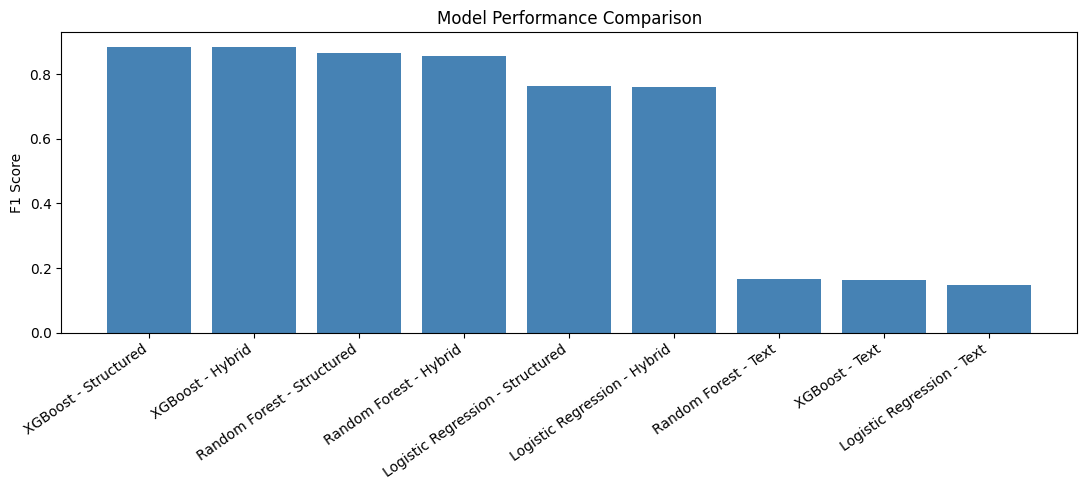

In [ ]:
plt.figure(figsize=(11, 5))
labels = results_df['Model'] + ' - ' + results_df['Features']
plt.bar(labels, results_df['F1 Score'], color='steelblue')
plt.xticks(rotation=35, ha='right')
plt.ylabel('F1 Score')
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()

best model: XGBoost on Structured features


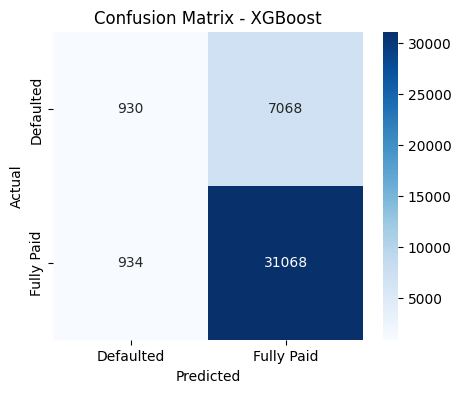

In [ ]:
best_row = results_df.iloc[0]
print("best model:", best_row['Model'], "on", best_row['Features'], "features")

best_model, best_X_test = trained_models[(best_row['Model'], best_row['Features'])]
y_pred_best = best_model.predict(best_X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Defaulted', 'Fully Paid'],
            yticklabels=['Defaulted', 'Fully Paid'])
plt.title('Confusion Matrix - ' + best_row['Model'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

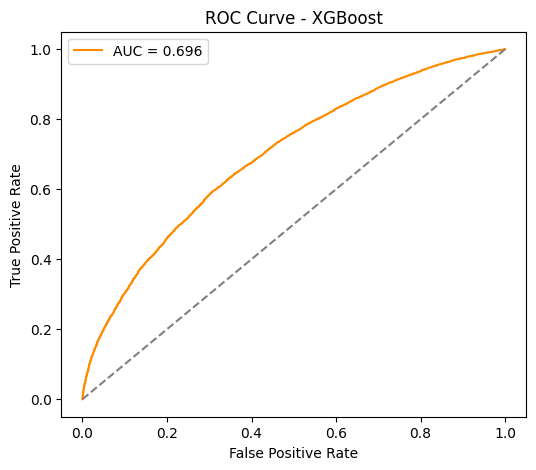

In [ ]:
y_prob_best = best_model.predict_proba(best_X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label='AUC = %.3f' % best_row['ROC-AUC'])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ' + best_row['Model'])
plt.legend()
plt.show()

In [ ]:
joblib.dump(best_model, '/content/drive/MyDrive/LoanProject/best_model.pkl')

print("phase 3 complete")
print("best model:", best_row['Model'], "on", best_row['Features'])
print("f1:", round(best_row['F1 Score'], 4), "| auc:", round(best_row['ROC-AUC'], 4))

phase 3 complete
best model: XGBoost on Structured
f1: 0.8859 | auc: 0.6965
